#**ANÁLISIS DE EVASIÖN DE CLIENTES PARTE II**

In [ ]:
import pandas as pd

In [19]:
df = pd.read_csv('/content/clientes_tratados.csv')

In [20]:
# limpiar df
df = df.drop(columns=['customerID'])

# verificar
print(df.columns)


Index(['Unnamed: 0', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Charges.Monthly',
       'Charges.Total', 'Cuentas_Diarias', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No'],
      dtype='object')


In [21]:
print(df.columns.tolist())


['Unnamed: 0', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'InternetService_Fiber optic', 'InternetService_No']


In [22]:
df.dtypes.value_counts()


,count
float64,11
bool,8
int64,6
object,1


In [23]:
df.select_dtypes(include='object').columns


Index(['gender'], dtype='object')

In [24]:
df['gender'] = df['gender'].replace({'Male':1, 'Female':0})


/tmp/ipython-input-3648116627.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male':1, 'Female':0})


In [25]:
df.dtypes.value_counts()

,count
float64,11
bool,8
int64,7


In [26]:
# conteo absoluto
print(df['Churn'].value_counts())

# proporción en porcentaje
print(df['Churn'].value_counts(normalize=True) * 100)


Churn
0.0    5163
1.0    1869
Name: count, dtype: int64
Churn
0.0    73.421502
1.0    26.578498
Name: proportion, dtype: float64


/tmp/ipython-input-2288533381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


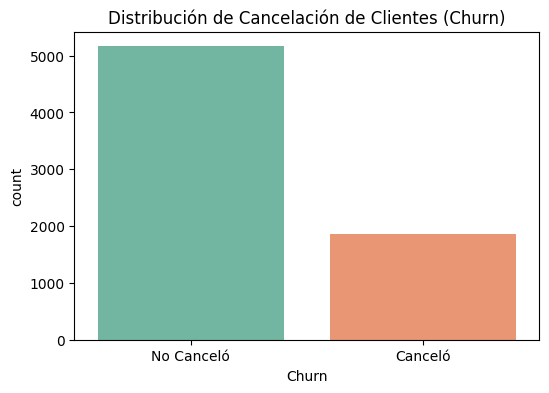

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribución de Cancelación de Clientes (Churn)')
plt.xticks([0,1], ['No Canceló','Canceló'])
plt.show()


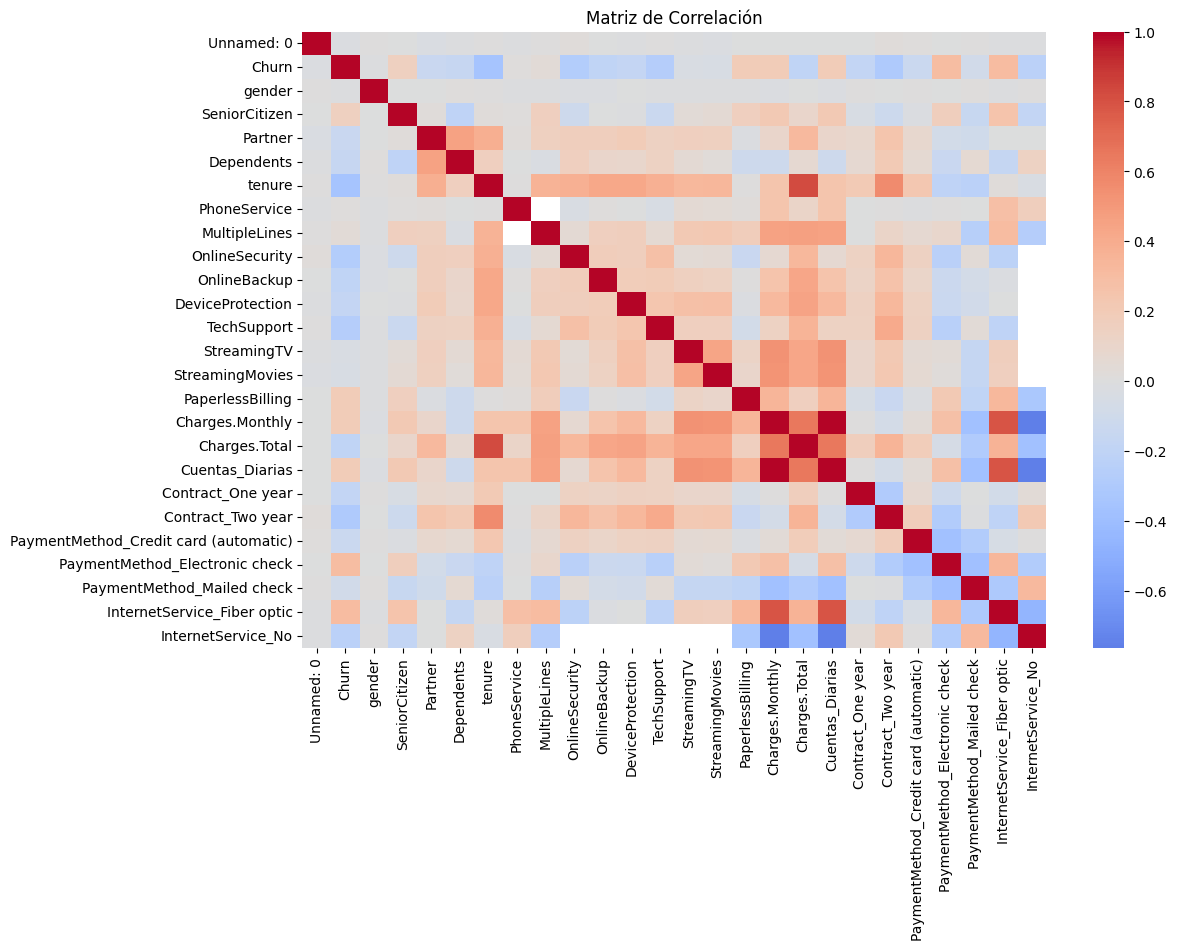

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# matriz de correlación
corr = df.corr()

# Visualizamos el heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()


In [35]:
corr_churn = corr['Churn'].sort_values(ascending=False)
print(corr_churn)


Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
Cuentas_Diarias                          0.192914
Charges.Monthly                          0.192858
PaperlessBilling                         0.191454
SeniorCitizen                            0.150541
MultipleLines                            0.040207
PhoneService                             0.011691
gender                                  -0.008545
Unnamed: 0                              -0.017868
StreamingTV                             -0.036698
StreamingMovies                         -0.040525
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner                                 -0.149982
Dependents                              -0.163128
DeviceProtection                        -0.176806
Contract_One year                       -0.178225
OnlineBackup                            -0.195758


In [36]:
df['Churn'].isna().sum()


np.int64(0)

In [37]:
# eliminar  las filas donde Churn es nulo
df = df.dropna(subset=['Churn'])

# verificar
print("Registros después de limpiar:", df.shape[0])
print("Nulos en Churn:", df['Churn'].isna().sum())


Registros después de limpiar: 7032
Nulos en Churn: 0


In [44]:
from sklearn.model_selection import train_test_split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Tamaño entrenamiento:", X_train.shape[0])
print("Tamaño prueba:", X_test.shape[0])

Tamaño entrenamiento: 4922
Tamaño prueba: 2110


In [45]:
num_cols  = X.select_dtypes(include=['float64','int64']).columns
bool_cols = X.select_dtypes(include=['bool']).columns


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1) Listas de columnas desde X (mayúscula)
num_cols  = X.select_dtypes(include=['float64','int64']).columns
bool_cols = X.select_dtypes(include=['bool']).columns

# 2) Pipelines de preprocesamiento
num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler())
])

# Convertimos bool -> float antes de imputar
bool_pipe = Pipeline([
    ('tofloat', FunctionTransformer(lambda a: a.astype(float))),
    ('imp',     SimpleImputer(strategy='most_frequent'))
])

prep_logreg = ColumnTransformer(
    transformers=[
        ('num',  num_pipe,  num_cols),
        ('bool', bool_pipe, bool_cols),
    ],
    remainder='drop'
)

logreg_pipeline = Pipeline([
    ('prep',  prep_logreg),
    ('model', LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_log = logreg_pipeline.predict(X_test)

print("Regresión Logística")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Regresión Logística
Accuracy: 0.8023696682464455
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



Random Forest
Accuracy: 0.7843601895734598
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1549
         1.0       0.62      0.48      0.54       561

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110

ROC AUC: 0.826604824687079


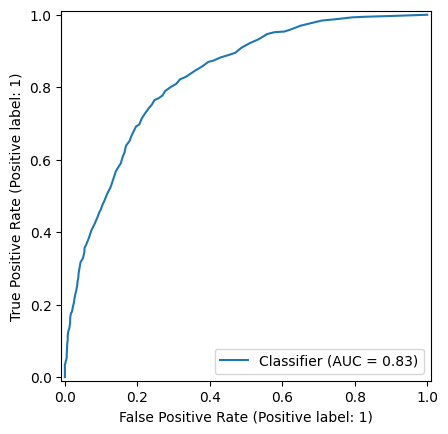

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

# Reutilizamos num_cols y bool_cols ya definidos
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler())
])
bool_pipe = Pipeline([
    ('tofloat', FunctionTransformer(lambda a: a.astype(float))),
    ('imp',     SimpleImputer(strategy='most_frequent'))
])

prep_rf = ColumnTransformer(
    transformers=[
        ('num',  num_pipe,  num_cols),
        ('bool', bool_pipe, bool_cols),
    ],
    remainder='drop'
)

rf_pipeline = Pipeline([
    ('prep',  prep_rf),
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf  = rf_pipeline.predict(X_test)
y_prob_rf  = rf_pipeline.predict_proba(X_test)[:,1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

RocCurveDisplay.from_predictions(y_test, y_prob_rf)


Logistic ROC AUC: 0.8454640967837337


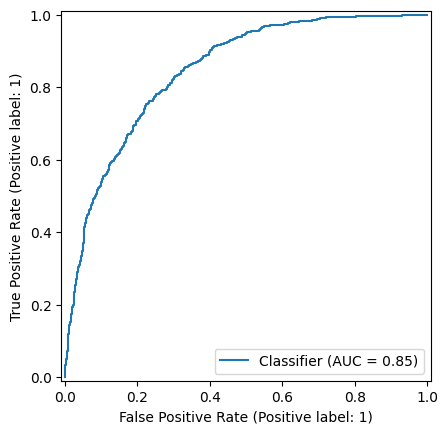

In [48]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Probabilidades para ROC–AUC
y_prob_log = logreg_pipeline.predict_proba(X_test)[:,1]
print("Logistic ROC AUC:", roc_auc_score(y_test, y_prob_log))

RocCurveDisplay.from_predictions(y_test, y_prob_log)


In [49]:
import pandas as pd

res = pd.DataFrame({
    'modelo': ['LogisticRegression','RandomForest'],
    'accuracy': [
        accuracy_score(y_test, logreg_pipeline.predict(X_test)),
        accuracy_score(y_test, y_pred_rf)
    ],
    'roc_auc': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})
print(res)


               modelo  accuracy   roc_auc
0  LogisticRegression   0.80237  0.845464
1        RandomForest   0.78436  0.826605


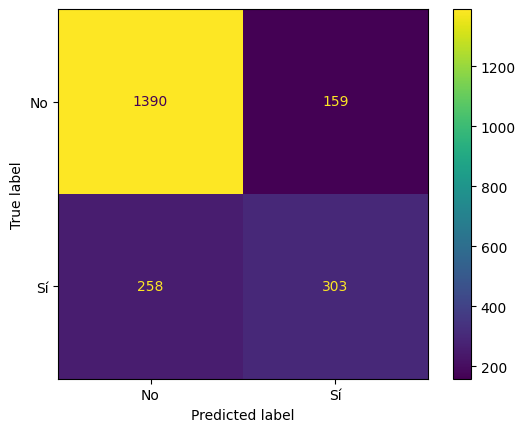

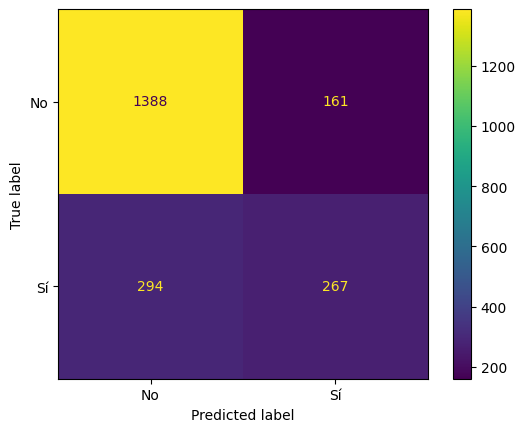

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, logreg_pipeline.predict(X_test), display_labels=['No','Sí'])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['No','Sí'])


In [51]:
import numpy as np
thr = 0.35  # prueba 0.35–0.45
y_thr = (y_prob_log >= thr).astype(int)

print("Logistic (threshold =", thr, ")")
print(classification_report(y_test, y_thr))


Logistic (threshold = 0.35 )
              precision    recall  f1-score   support

         0.0       0.88      0.80      0.84      1549
         1.0       0.56      0.71      0.63       561

    accuracy                           0.77      2110
   macro avg       0.72      0.75      0.73      2110
weighted avg       0.80      0.77      0.78      2110




Modelo: Regresión Logística
Exactitud (Accuracy): 0.8023696682464455
Precisión: 0.6558441558441559
Recall: 0.5401069518716578
F1-score: 0.592375366568915

Modelo: Random Forest
Exactitud (Accuracy): 0.7843601895734598
Precisión: 0.6238317757009346
Recall: 0.47593582887700536
F1-score: 0.5399393326592518


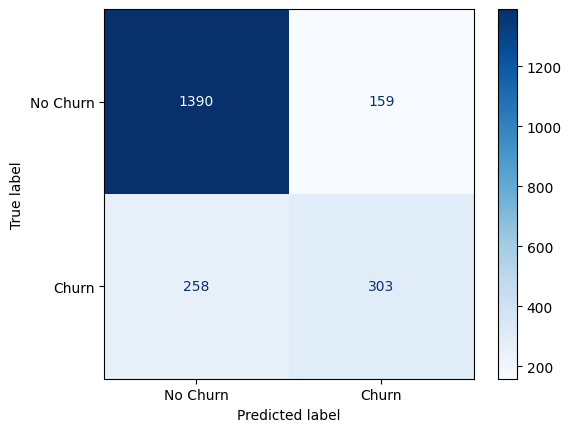

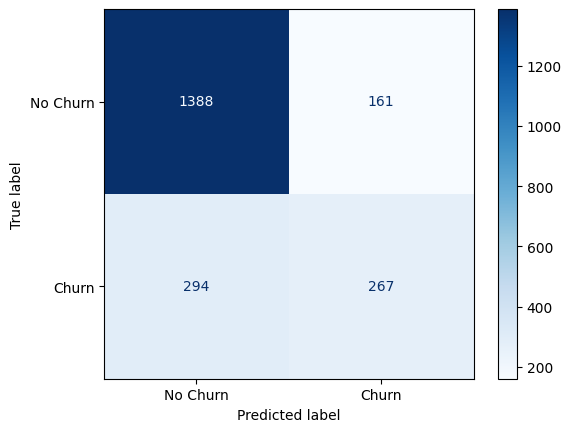

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# --- Función auxiliar para evaluar modelos ---
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    print(f"\nModelo: {nombre}")
    print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred))
    print("Precisión:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn','Churn'])
    disp.plot(cmap="Blues")

# --- Evaluar ambos ---
evaluar_modelo("Regresión Logística", logreg_pipeline, X_test, y_test)
evaluar_modelo("Random Forest", rf_pipeline, X_test, y_test)


In [53]:
# Importancia de variables en Regresión Logística
import pandas as pd

coefs = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": logreg_pipeline.named_steps['model'].coef_[0]
})
coefs = coefs.sort_values(by="Coeficiente", ascending=False)
print(coefs.head(10))   # top factores que aumentan churn
print(coefs.tail(10))   # top factores que reducen churn


                          Variable  Coeficiente
23     InternetService_Fiber optic     0.652997
15                 Charges.Monthly     0.640054
21  PaymentMethod_Electronic check     0.389811
17                 Cuentas_Diarias     0.256783
13                 StreamingMovies     0.182428
16                   Charges.Total     0.098739
11                     TechSupport     0.097280
6                     PhoneService     0.077296
12                     StreamingTV     0.046313
14                PaperlessBilling     0.044365
                                 Variable  Coeficiente
2                           SeniorCitizen    -0.047250
8                          OnlineSecurity    -0.081765
20  PaymentMethod_Credit card (automatic)    -0.084862
7                           MultipleLines    -0.144888
5                                  tenure    -0.168898
10                       DeviceProtection    -0.200761
18                      Contract_One year    -0.688248
24                     InternetS

📌 Resumen del Análisis de Cancelación de Clientes (Churn)

Tras comparar los modelos de Regresión Logística y Random Forest, se concluyó que:

Desempeño de los Modelos  
La Regresión Logística mostró mejores resultados generales, alcanzando una precisión cercana al 80%, junto con mejores valores de precisión y recall. Esto indica que, además de ser más simple, es un modelo más interpretable y equilibrado frente al Random Forest.

Variables Clave Asociadas al Churn  
Los factores más relevantes identificados fueron:

- Contratos mensuales: mayor tendencia a cancelar.  
- Internet de fibra óptica: vinculado a un alto nivel de churn.  
- Método de pago “Electronic Check”: se asocia con más cancelaciones.  
- Baja antigüedad (Tenure): los clientes nuevos tienden a cancelar más.  
- Cargos mensuales altos: correlacionan positivamente con la cancelación.

Recomendaciones para Retención  
A partir de estos hallazgos, se sugieren:

- Fomentar contratos de largo plazo con incentivos.  
- Mejorar el servicio de fibra óptica.  
- Impulsar métodos de pago automáticos o domiciliados.  
- Implementar programas de retención para nuevos clientes.  
- Ofrecer beneficios personalizados a quienes tienen altos cargos mensuales.